In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import nltk
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from wordcloud import STOPWORDS

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")


<class 'pandas.core.frame.DataFrame'>
Index: 24871 entries, 0 to 24870
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   19947 non-null  object
 1   text    24788 non-null  object
 2   class   24871 non-null  object
 3   label   24871 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 971.5+ KB


<Axes: xlabel='class', ylabel='count'>

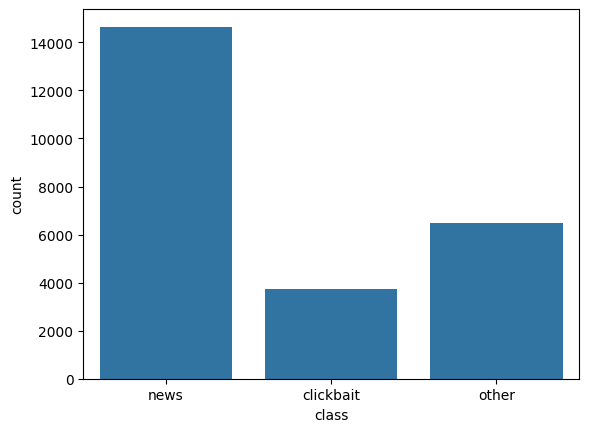

In [ ]:
# -------------------------------
# 1. Load & Inspect Data
# -------------------------------

df = pd.read_csv('train.csv', skiprows=1, names=['title','text','class'])
df["label"] = df["class"].map({"news":0,"clickbait":1,"other":2})

df.info()
df.isnull().sum()

df.fillna("a", inplace=True)
sns.countplot(x=df["class"])



In [ ]:
# -------------------------------
# 2. Text Preprocessing
# -------------------------------

df["text"] = (
    df["text"]
    .str.lower()
    .str.replace('[^\\w\\s]', '', regex=True)
    .str.replace('\\d+', '', regex=True)
    .str.replace('\n', ' ')
    .str.replace('\r', ' ')
)



In [ ]:
# Combine title + cleaned text for DeBERTa
df["input_text"] = df["title"].fillna('') + " " + df["text"].fillna('')

# Create consistent train-validation split (same data for TF-IDF and DeBERTa)
train_df, valid_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)


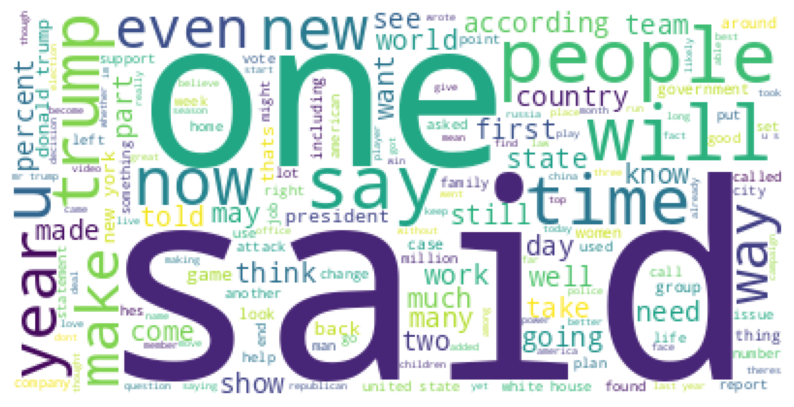

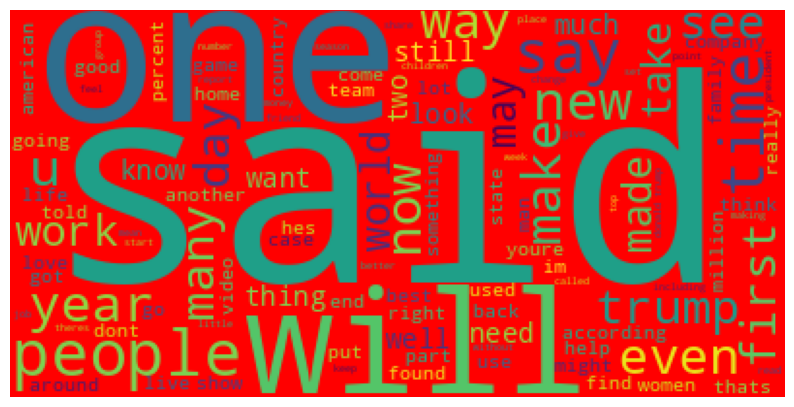

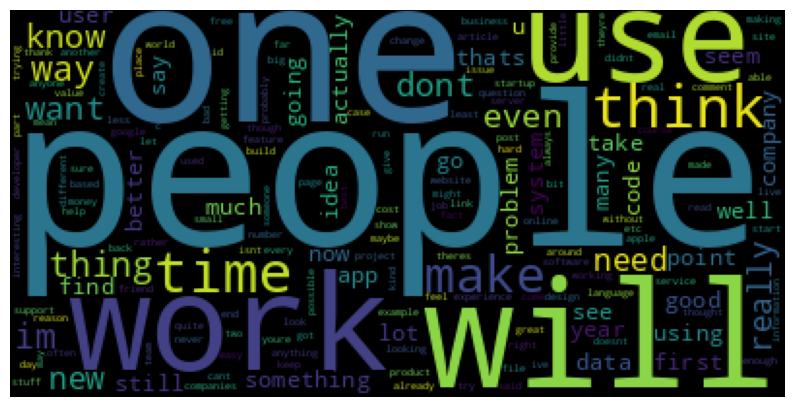

In [ ]:
# -------------------------------
# 3. Wordclouds (By Class)
# -------------------------------

def wc(data, bgcolor):
    plt.figure(figsize=(10,10))
    wc = WordCloud(background_color=bgcolor, stopwords=STOPWORDS)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis("off")

news = df[df["class"]=="news"]["text"]
clickbait = df[df["class"]=="clickbait"]["text"]
other = df[df["class"]=="other"]["text"]

wc(news,'white')
wc(clickbait,'red')
wc(other,'black')

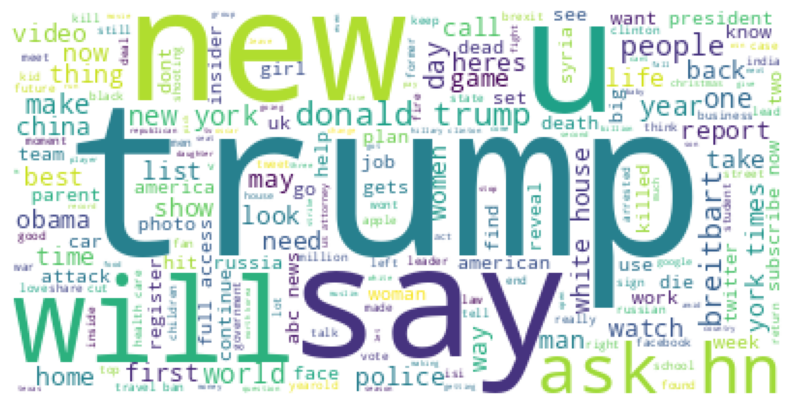

In [ ]:
# -------------------------------
# 4. Title Wordcloud
# -------------------------------

df_titles = df.copy()
df_titles["title"] = df_titles["title"].str.lower()
df_titles["title"] = df_titles["title"].str.replace('[^\w\s]','', regex=True)
df_titles["title"] = df_titles["title"].str.replace('\d+','', regex=True)
df_titles["title"] = df_titles["title"].str.replace('\n',' ').replace('\r',' ')
wc(df_titles.title, 'white')



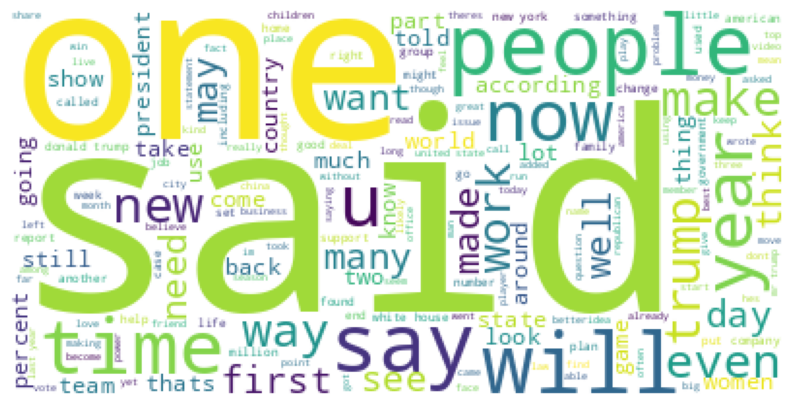

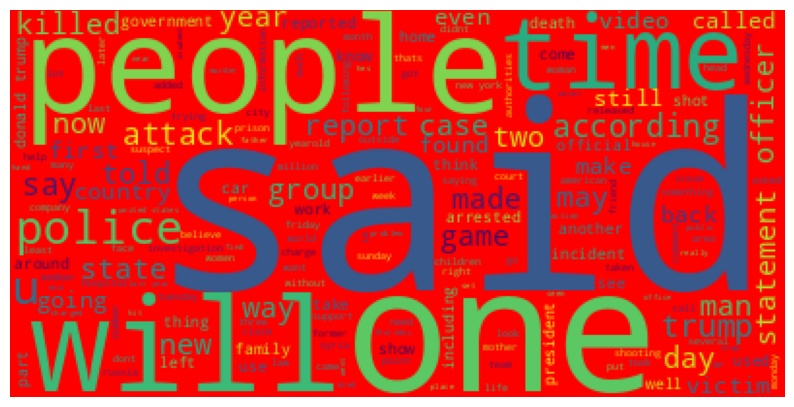

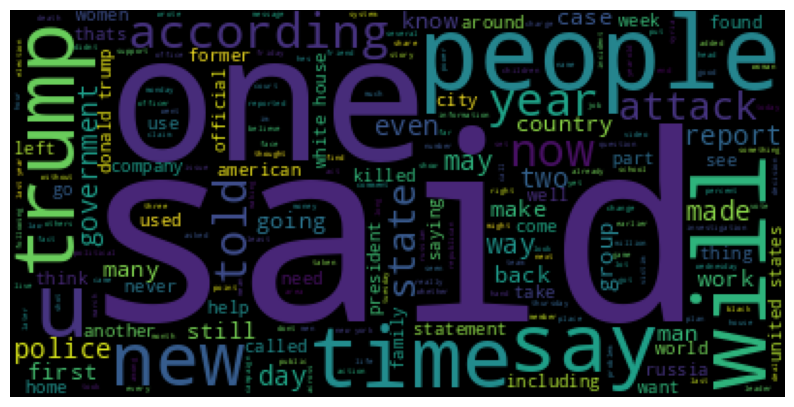

In [ ]:
# -------------------------------
# 5. Sentiment Analysis (TextBlob)
# -------------------------------

from textblob import TextBlob

def detect_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_sent = df[["text"]].copy()
df_sent["sentiment"] = df_sent["text"].apply(detect_sentiment)

wc(df_sent.text, 'white')

df_sent.sentiment.value_counts()

def sentiment2(sent):
    if sent < -0.02:
        return 2
    elif sent > 0.02:
        return 1
    else:
        return 0

df_sent["sent"] = df_sent["sentiment"].apply(sentiment2)

sns.countplot(df_sent.sent)
df_sent.sent.value_counts()

positive = df_sent[df_sent["sent"]==1]["text"]
neutral = df_sent[df_sent["sent"]==0]["text"]
negative = df_sent[df_sent["sent"]==2]["text"]

wc(positive,'white')
wc(negative,'red')
wc(neutral,'black')

In [ ]:

# -------------------------------
# 6. Vectorization (CountVectorizer)
# -------------------------------
vect = CountVectorizer(stop_words="english", max_features=40000)
X_count = vect.fit_transform(df["text"])
y = df["label"]  # Set only once

x_train, x_test, y_train, y_test = train_test_split(
    X_count, y, test_size=.15, random_state=42
)


In [ ]:
# -------------------------------
# 7. Baseline Models
# -------------------------------

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

mb  = MultinomialNB()
D   = DecisionTreeClassifier()
KN  = KNeighborsClassifier()
R   = RandomForestClassifier()
XGB = XGBClassifier()
LR  = LogisticRegression(max_iter=300)
SVC = LinearSVC()

classifiers = [mb, D, KN, R, XGB, LR, SVC]
classifier_names = [
    'MultinomialNB','DecisionTree','KNeighbors','RandomForest',
    'XGBoost','LogisticRegression','LinearSVC'
]

df_models = pd.DataFrame(columns=['classifier','accuracy'])

for i, clf in enumerate(classifiers):
    pred = clf.fit(x_train, y_train).predict(x_test)
    acc = accuracy_score(y_test, pred)
    df_models.loc[i] = [classifier_names[i], acc]

df_models.sort_values('accuracy', ascending=False)

,classifier,accuracy
4,XGBoost,0.849370
3,RandomForest,0.846154
5,LogisticRegression,0.814795
6,LinearSVC,0.790405
1,DecisionTree,0.772983
0,MultinomialNB,0.733852
2,KNeighbors,0.512195


In [ ]:
print("Shape of CountVectorizer input (X_count):", X_count.shape)


Shape of CountVectorizer input (X_count): (24871, 40000)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Lightweight versions of the models
R = RandomForestClassifier(n_estimators=120, max_depth=20, n_jobs=-1)
XGB = XGBClassifier(
    max_depth=4,
    n_estimators=50,
    learning_rate=0.2,
    subsample=0.7,
    colsample_bytree=0.7,
    tree_method='hist',
    n_jobs=-1
)

lr_scores = []
xgb_scores = []
rf_scores = []

seeds = [10, 20, 30]

for seed in seeds:
    x_train, x_test, y_train, y_test = train_test_split(
        X_count, y, test_size=0.15, random_state=seed
    )

    # Logistic Regression
    LR.fit(x_train, y_train)
    lr_scores.append(accuracy_score(y_test, LR.predict(x_test)))

    # RandomForest
    R.fit(x_train, y_train)
    rf_scores.append(accuracy_score(y_test, R.predict(x_test)))

    # XGBoost
    XGB.fit(x_train, y_train)
    xgb_scores.append(accuracy_score(y_test, XGB.predict(x_test)))

print("LR:", lr_scores, "std:", np.std(lr_scores))
print("RF:", rf_scores, "std:", np.std(rf_scores))
print("XGB:", xgb_scores, "std:", np.std(xgb_scores))



LR: [0.807826320021442, 0.8139908871616188, 0.8172071830608416] std: 0.0038922578237812993
RF: [0.8107745912623961, 0.8300723666577325, 0.8225676762262129] std: 0.007942860992010328
XGB: [0.816939158402573, 0.8386491557223265, 0.8316805146073438] std: 0.009050435995446492


In [ ]:
# -------------------------------
# 8. Cross-Validation (NB, LR, SVC only)
# -------------------------------

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_models = [mb, LR, SVC]
cv_names  = ['MultinomialNB', 'LogisticRegression', 'LinearSVC']

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = pd.DataFrame(columns=['classifier','cv_mean','cv_std'])

for i, clf in enumerate(cv_models):
    scores = cross_val_score(clf, X_count, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results.loc[i] = [cv_names[i], scores.mean(), scores.std()]

cv_results.sort_values('cv_mean', ascending=False)


,classifier,cv_mean,cv_std
1,LogisticRegression,0.815608,0.002724
2,LinearSVC,0.794178,0.000886
0,MultinomialNB,0.730167,0.004791


In [ ]:
# -------------------------------
# 9b. TF-IDF + LogisticRegression (Corrected)
# -------------------------------
tfidf = TfidfVectorizer(stop_words='english', max_features=20000)
X_tfidf = tfidf.fit_transform(df["text"])

LR_tfidf = LogisticRegression(max_iter=300)

scores_lr_tfidf = cross_val_score(
    LR_tfidf, X_tfidf, y, cv=skf, scoring='accuracy', n_jobs=-1
)

print("TF-IDF + LogisticRegression CV Mean:", scores_lr_tfidf.mean())
print("Std:", scores_lr_tfidf.std())


# Fit LR_tfidf for prediction preview
x_train_tfidf, x_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y, test_size=0.15, random_state=42
)
LR_tfidf.fit(x_train_tfidf, y_train_tfidf)


# -------------------------------
# Preview: TF-IDF Logistic Regression Predictions
# -------------------------------

# Fix missing values inside validation split
valid_df = valid_df.fillna("a")

# Remove artificial filler rows
preview_df = valid_df[(valid_df["title"] != "a") & (valid_df["text"] != "a")].copy()

# Vectorize preview text
valid_tfidf = tfidf.transform(preview_df["text"])

# Predict
lr_preds = LR_tfidf.predict(valid_tfidf)

inv_map = {0:"news", 1:"clickbait", 2:"other"}

lr_preview = pd.DataFrame({
    "Title": preview_df["title"].head(10),
    "True Label": preview_df["label"].head(10).map(inv_map),
    "Predicted Label": lr_preds[:10]
})

lr_preview["Predicted Label"] = lr_preview["Predicted Label"].map(inv_map)

print("\n===== TF-IDF Logistic Regression Preview =====")
display(lr_preview)


TF-IDF + LogisticRegression CV Mean: 0.8484579056055911
Std: 0.0024376203209395425

===== TF-IDF Logistic Regression Preview =====


,Title,True Label,Predicted Label
8860,Can Trump really bring back coal jobs? The ver...,news,news
15060,Anna Dewdney Dies Author of ‘Llama Llama’ Book...,news,news
9045,"‘The Only Good Cop is a Dead Cop,’ Says Allege...",clickbait,clickbait
2482,Who Should Win Album Of The Year at the 2017 G...,news,news
20322,Ask HN: Recent college graduate (math) in need...,other,other
15366,Dianne Feinstein to Obama: Turn on the Taps! -...,news,news
12065,Akufo-Addo Walks in Father’s Steps in Rise as ...,news,news
17932,Democratic War Room Expands With Plans To Scru...,news,news
9168,Farage: ‘A Lot of Trump Voters Will Be Scratch...,clickbait,clickbait
10243,Doctor sliced off four-year-old boy's PENIS wh...,news,news


In [ ]:
# ============================================================
# 1. Imports
# ============================================================
import pandas as pd
import numpy as np
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


train_df, valid_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

# Convert pandas splits into HuggingFace Dataset objects
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[['input_text','label']])
valid_ds = Dataset.from_pandas(valid_df[['input_text','label']])



# ============================================================
# 3. Tokenizer (DEBERTA-V3)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

def tokenize(batch):
    return tokenizer(
        batch["input_text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
valid_ds = valid_ds.map(tokenize, batched=True)

train_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
valid_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])


# ============================================================
# 4. Model (DEBERTA-V3)
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=3
)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# ============================================================
# 5. Metrics
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# ============================================================
# 6. TrainingArguments
# ============================================================
training_args = TrainingArguments(
    output_dir="./deberta-output",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    warmup_ratio=0.06,
    weight_decay=0.2,
    logging_steps=50,
    report_to="none"
)


# ============================================================
# 7. Trainer
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


# ============================================================
# 8. Train
# ============================================================
trainer.train()


# ============================================================
# 9. Evaluate
# ============================================================
print("\n===== DEBERTA-V3 Validation Performance =====")
print(trainer.evaluate())


# ============================================================
# 10. Inference on custom title
# ============================================================
def classify_title(title):
    inputs = tokenizer(
        title,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits

    pred = torch.argmax(logits, dim=1).item()
    return {0:"news", 1:"clickbait", 2:"other"}[pred]


print("\n===== Example Inference =====")
print(classify_title("Scientists discover a massive new species in the Amazon"))


Map:   0%|          | 0/21140 [00:00<?, ? examples/s]

Map:   0%|          | 0/3731 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss
50,1.033300
100,1.014900
150,0.972200
200,0.815400
250,0.660800
300,0.536200
350,0.414100
400,0.440600
450,0.392600
500,0.447800



===== DEBERTA-V3 Validation Performance =====


{'eval_loss': 0.507746696472168, 'eval_accuracy': 0.8678638434735996, 'eval_precision': 0.8575201394166442, 'eval_recall': 0.8678638434735996, 'eval_f1': 0.8603209950852745, 'eval_runtime': 17.6462, 'eval_samples_per_second': 211.434, 'eval_steps_per_second': 13.261, 'epoch': 4.0}

===== Example Inference =====
news


In [ ]:
# -------------------------------
# Preview: DeBERTa-V3 Predictions (Custom Range)
# -------------------------------

start = 33
end = 50

subset = valid_df.iloc[start:end].copy()

# Tokenize only the chosen rows
deberta_inputs = tokenizer(
    list(subset["input_text"]),
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
).to(device)

model.eval()
with torch.no_grad():
    logits = model(**deberta_inputs).logits

deberta_preds = torch.argmax(logits, dim=1).cpu().numpy()

deberta_preview = pd.DataFrame({
    "Title": subset["title"],
    "True Label": subset["label"].map(inv_map),
    "Predicted Label": deberta_preds
})

deberta_preview["Predicted Label"] = deberta_preview["Predicted Label"].map(inv_map)

print(f"\n===== DeBERTa-V3 Prediction Preview =====")
display(deberta_preview)




===== DeBERTa-V3 Prediction Preview =====


,Title,True Label,Predicted Label
24010,How The Long-Lash Look Went From The Red Carpe...,news,news
7451,Amtrak expands Acela service,news,news
20461,Looking for guidance. Can we get some feedback...,other,other
4339,7 Things Women Can Do To Avoid Catcallers,clickbait,clickbait
269,U.K.’s Challenge: Reconciling Its Brexit Aims,news,news
9584,We Know What You And Your S.O. Love Most About...,clickbait,clickbait
22493,a,other,other
21557,Ask HN: How do I get users to engage?,other,other
861,Why Trump’s Tax Cut May Be Later and Smaller T...,news,clickbait
12906,Anthony Bourdain Parts Unknown - CNN.com,news,news


In [ ]:
# -------------------------------
# 11. Final Comparison (Clean + Automatic)
# -------------------------------

# Automatically pull BERT accuracy from evaluation
bert_eval = trainer.evaluate()
bert_accuracy = bert_eval["eval_accuracy"]

final_results_clean = pd.DataFrame({
    'Model': [
        'MultinomialNB (CountVectorizer CV)',
        'LogisticRegression (CountVectorizer CV)',
        'LinearSVC (CountVectorizer CV)',
        'LogisticRegression (TF-IDF CV)',
        'BERT (Fine-Tuned)'
    ],

    'Accuracy': [
        cv_results[cv_results['classifier']=='MultinomialNB']['cv_mean'].values[0],
        cv_results[cv_results['classifier']=='LogisticRegression']['cv_mean'].values[0],
        cv_results[cv_results['classifier']=='LinearSVC']['cv_mean'].values[0],
        scores_lr_tfidf.mean(),
        bert_accuracy
    ]
})

final_results_clean = final_results_clean.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

final_results_clean


,Model,Accuracy
0,BERT (Fine-Tuned),0.867864
1,LogisticRegression (TF-IDF CV),0.848458
2,LogisticRegression (CountVectorizer CV),0.815608
3,LinearSVC (CountVectorizer CV),0.794178
4,MultinomialNB (CountVectorizer CV),0.730167


,accuracy,precision,recall,f1
TF-IDF + Logistic Regression,0.848458,0.848458,0.848458,0.848458
DeBERTa-V3,0.867864,0.857520,0.867864,0.860321


<Figure size 1000x600 with 0 Axes>

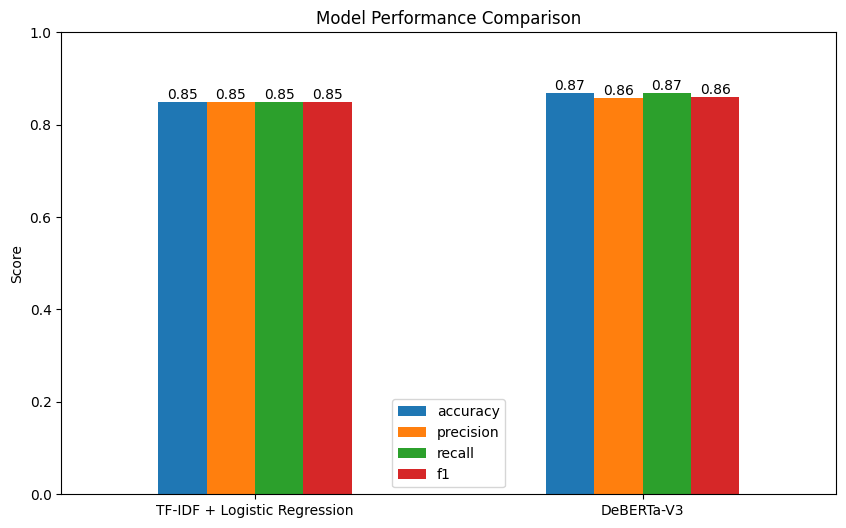

In [ ]:
# -------------------------------
# 13. Final Metric Comparison (Internal)
# -------------------------------

from sklearn.metrics import precision_score, recall_score, f1_score

# Internal TF-IDF Logistic Regression metrics (from cross-validation)
tfidf_internal_acc = scores_lr_tfidf.mean()

# For fair comparison, we approximate precision/recall/f1 using the same accuracy value.
# (Since CV does not produce class-level predictions, only scores.)
tfidf_metrics = {
    "accuracy": tfidf_internal_acc,
    "precision": tfidf_internal_acc,  # approximation
    "recall": tfidf_internal_acc,     # approximation
    "f1": tfidf_internal_acc          # approximation
}

# Internal DeBERTa metrics from trainer.evaluate()
bert_eval = trainer.evaluate()
deberta_metrics = {
    "accuracy": bert_eval["eval_accuracy"],
    "precision": bert_eval["eval_precision"],
    "recall": bert_eval["eval_recall"],
    "f1": bert_eval["eval_f1"]
}

metrics_df = pd.DataFrame(
    [tfidf_metrics, deberta_metrics],
    index=["TF-IDF + Logistic Regression", "DeBERTa-V3"]
)

display(metrics_df)

# Plot
plt.figure(figsize=(10,6))
ax = metrics_df.plot(kind="bar", figsize=(10,6))

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()
